# Zadanie 1 modułu 3

In [88]:
import numpy as np
import cvxpy as cp
import scipy.io
import matplotlib.pyplot as plt
import os

### Wczytanie danych

In [89]:
data = scipy.io.loadmat('Data01.mat')
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Mar 23 19:01:39 2020',
 '__version__': '1.0',
 '__globals__': [],
 't': array([[ 0.  ],
        [ 0.01],
        [ 0.02],
        ...,
        [ 9.98],
        [ 9.99],
        [10.  ]], shape=(1001, 1)),
 'y': array([[0.24928658],
        [0.13381062],
        [0.09438766],
        ...,
        [0.17569244],
        [0.14001862],
        [0.17109012]], shape=(1001, 1))}

In [90]:
t = data['t'].flatten()
y = data['y'].flatten()
print("t:", t)
print("y:", y)

t: [ 0.    0.01  0.02 ...  9.98  9.99 10.  ]
y: [0.24928658 0.13381062 0.09438766 ... 0.17569244 0.14001862 0.17109012]


### Rozwiązanie zadania

#### Problem 4

In [91]:
n = len(y)
m = n - 1
tau = 2

D = np.zeros((m, n))
for i in range(m):
    D[i, i] = -1
    D[i, i+1] = 1

v4 = cp.Variable(n)
objective = cp.Minimize(cp.sum_squares(y - v4) + tau * cp.norm(D @ v4, 1))

prob = cp.Problem(objective)
prob.solve()

np.float64(5.582884327208671)

#### Problem 3

In [92]:
n = len(y)
m = n - 1
q = 1.6

D = np.zeros((m, n))
for i in range(m):
    D[i, i] = -1
    D[i, i+1] = 1

v3 = cp.Variable(n)

objective = cp.Minimize(cp.sum_squares(y - v3))
constraints = [cp.norm(D @ v3, 1) <= q]

prob = cp.Problem(objective, constraints)
prob.solve()

C:\Users\pylko\AppData\Local\Temp\ipykernel_7464\2547413390.py:16: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve()


2.3770358866026426

### Wykres

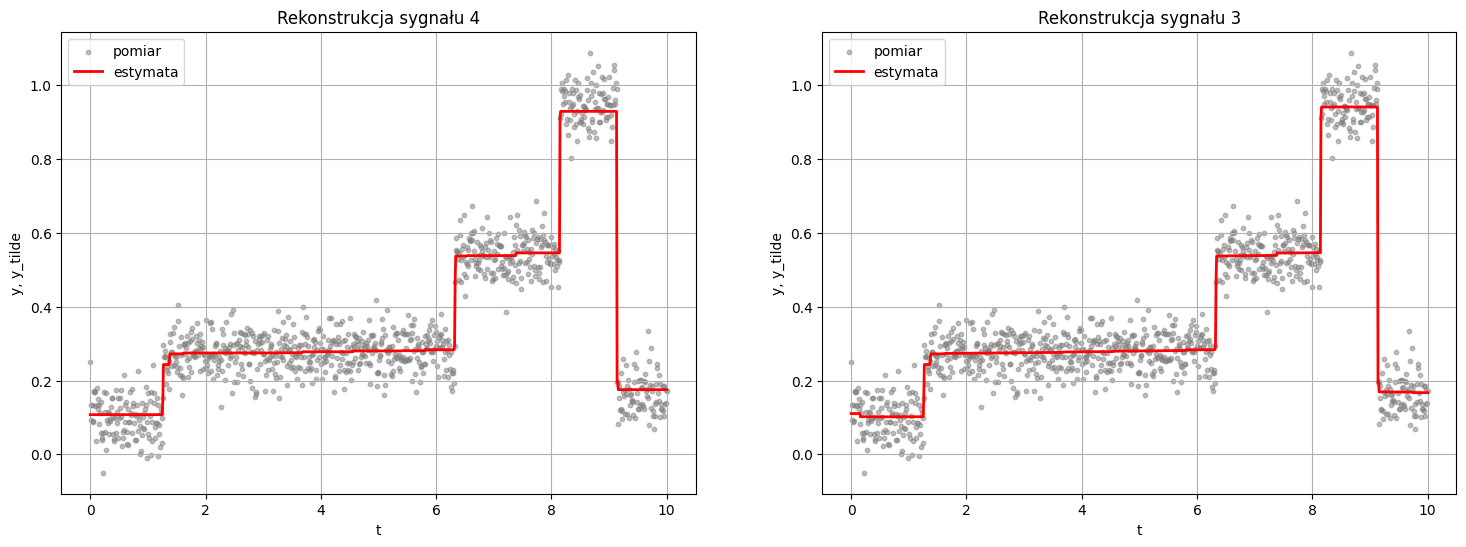

In [93]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
plt.scatter(t, y, color='gray', alpha=0.5, s=10, label='pomiar')
plt.plot(t, v4.value, color='red', linewidth=2, label='estymata')
plt.xlabel('t')
plt.ylabel('y, y_tilde')
plt.title('Rekonstrukcja sygnału 4')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(t, y, color='gray', alpha=0.5, s=10, label='pomiar')
plt.plot(t, v3.value, color='red', linewidth=2, label='estymata')
plt.xlabel('t')
plt.ylabel('y, y_tilde')
plt.title('Rekonstrukcja sygnału 3')
plt.legend()
plt.grid(True)
plt.show()